# TASK 1: Credit Scoring **Model**
# Credit Scoring Model using Machine Learning

**Internship:** CodeAlpha Machine Learning Internship  
**Task:** Credit Scoring Model  
**Dataset:** German Credit Risk Dataset  

### Objective
The goal of this project is to predict whether an individual is a **Good Credit** or **Bad Credit** risk based on financial and personal attributes using Machine Learning techniques.


### Importing Required Libraries

- **Pandas & NumPy** for data handling  
- **Matplotlib & Seaborn** for visualization  
- **Scikit-learn** for ML models and preprocessing  
- **SMOTE** to handle class imbalance  
- **Joblib** to save the trained model

In [23]:
#Import all required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from joblib import dump

import warnings
warnings.filterwarnings("ignore")


### Loading the Dataset

The German Credit Risk dataset contains financial and personal information of customers along with their credit risk status.

In [24]:
# Load German Credit Risk Dataset
df = pd.read_csv("german_credit_data.csv")
df.head()


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


### Dataset Overview

This step helps us understand:
- Number of rows and columns  
- Data types  
- Missing values  
- Overall structure of the dataset



In [25]:
df.shape

(1000, 21)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


In [27]:
df.describe()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,...,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,1.145000,...,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.845000,1.404000,1.963000,0.700000
std,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,...,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856,0.458487
min,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,1.000000,...,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,1.000000,...,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000
50%,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,1.000000,...,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000
75%,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,1.000000,...,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,3.000000,...,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000


In [28]:
df.isnull().sum()

,0
laufkont,0
laufzeit,0
moral,0
verw,0
hoehe,0
sparkont,0
beszeit,0
rate,0
famges,0
buerge,0


### Target Variable Encoding

The dataset contains a column named **kredit**:
- `good` → 0 (Good Credit)
- `bad` → 1 (Bad Credit)

We convert it into a binary target variable for machine learning.


In [29]:
# Convert Risk column to binary target (assuming 'kredit' is the target column)

df['target'] = df['kredit'].map({
    1: 0,  # Assuming original 'kredit' 1 represents 'good' credit
    0: 1   # Assuming original 'kredit' 0 represents 'bad' credit
})

df.drop(columns=['kredit'], inplace=True) # Drop 'kredit' column after conversion

df['target'].value_counts()

,count
target,
0,700
1,300


### Feature & Target Separation

We separate:
- **X** → Input features  
- **y** → Target variable  

We also identify numerical and categorical columns.


In [30]:
TARGET = "target"

X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numeric_cols, categorical_cols


(['laufkont',
  'laufzeit',
  'moral',
  'verw',
  'hoehe',
  'sparkont',
  'beszeit',
  'rate',
  'famges',
  'buerge',
  'wohnzeit',
  'verm',
  'alter',
  'weitkred',
  'wohn',
  'bishkred',
  'beruf',
  'pers',
  'telef',
  'gastarb'],
 [])

### Train-Test Split

The dataset is split into:
- **80% Training Data**
- **20% Testing Data**

This helps evaluate model performance on unseen data.


In [31]:
#Train / Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape


((800, 20), (200, 20))

### Data Preprocessing

- Missing values handling  
- Scaling numerical features  
- Encoding categorical features  

A preprocessing pipeline ensures clean and consistent data.


In [32]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])


### Handling Class Imbalance

The dataset is imbalanced.  
**SMOTE (Synthetic Minority Oversampling Technique)** is applied to balance both classes.


In [33]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train_prep, y_train)

y_resampled.value_counts()


,count
target,
1,560
0,560


### Model Training

We train multiple models:
- Logistic Regression  
- Decision Tree  
- Random Forest  

This allows performance comparison.


In [34]:
#Train baseline models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name} ...")
    model.fit(X_resampled, y_resampled)
    trained_models[name] = model



Training Logistic Regression ...

Training Decision Tree ...

Training Random Forest ...


### Model Evaluation

Models are evaluated using:
- Confusion Matrix  
- Precision, Recall, F1-Score  
- ROC-AUC Curve


In [35]:
#Evaluation function for reuse

def evaluate(name, model):
    print(f"\n===== {name} =====")

    y_pred = model.predict(X_test_prep)
    y_prob = model.predict_proba(X_test_prep)[:,1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.show()


Evaluate All Models


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.82      0.71      0.76       140
           1       0.49      0.65      0.56        60

    accuracy                           0.69       200
   macro avg       0.66      0.68      0.66       200
weighted avg       0.72      0.69      0.70       200

ROC-AUC Score: 0.7226190476190475


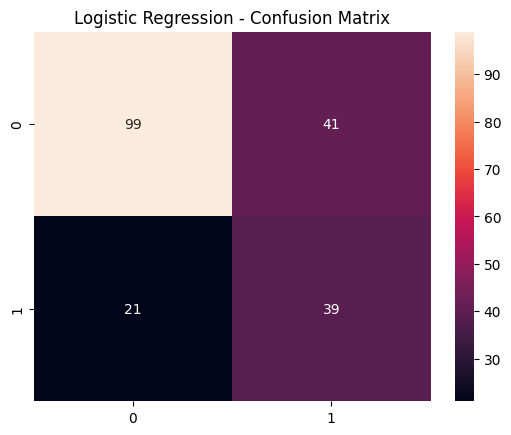

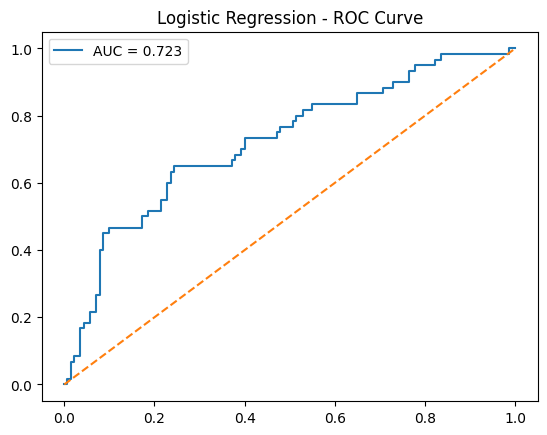


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.81      0.63      0.71       140
           1       0.43      0.65      0.52        60

    accuracy                           0.64       200
   macro avg       0.62      0.64      0.61       200
weighted avg       0.69      0.64      0.65       200

ROC-AUC Score: 0.6392857142857142


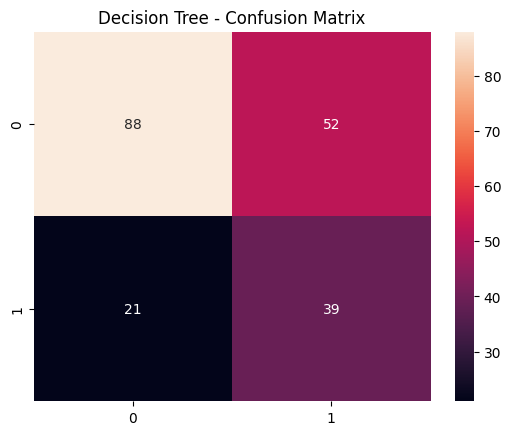

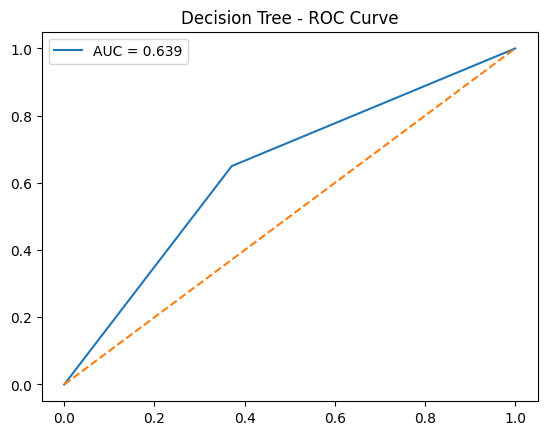


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       140
           1       0.60      0.45      0.51        60

    accuracy                           0.74       200
   macro avg       0.69      0.66      0.67       200
weighted avg       0.73      0.74      0.73       200

ROC-AUC Score: 0.7670833333333333


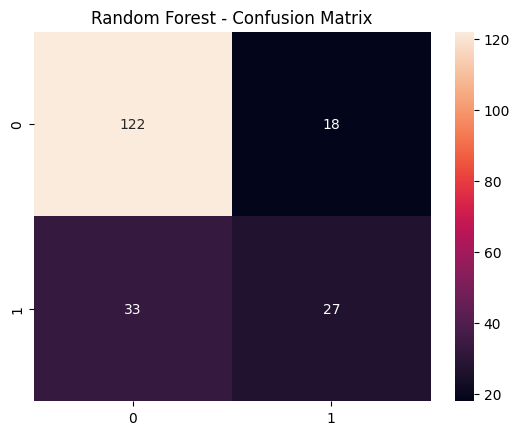

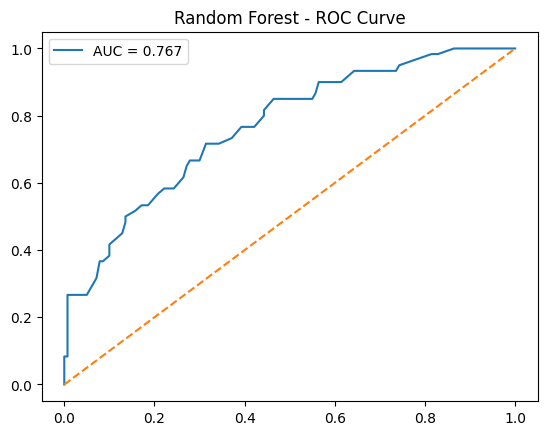

In [36]:
#Evaluate all models

for name, model in trained_models.items():
    evaluate(name, model)


# Hyperparameter Tuning (Random Forest)
Optional but gives HIGH accuracy

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

===== Random Forest (Tuned) =====
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       140
           1       0.61      0.45      0.52        60

    accuracy                           0.75       200
   macro avg       0.70      0.66      0.68       200
weighted avg       0.74      0.75      0.74       200

ROC-AUC Score: 0.7813690476190476


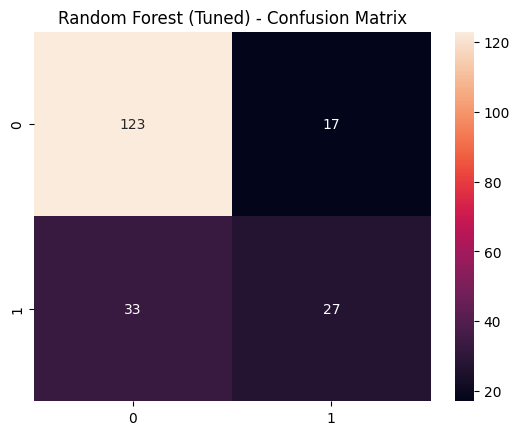

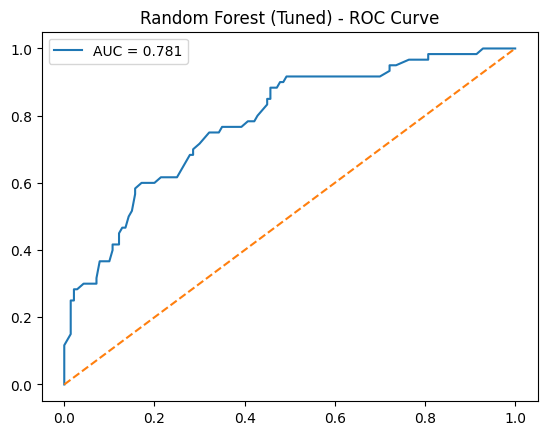

In [37]:
#Hyperparameter tuning for Random Forest

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid.fit(X_resampled, y_resampled)

print("Best parameters:", grid.best_params_)
best_rf = grid.best_estimator_

evaluate("Random Forest (Tuned)", best_rf)


Save Best Model Pipeline

In [38]:
#Save final pipeline

from sklearn.pipeline import make_pipeline

final_model = make_pipeline(preprocessor, best_rf)
dump(final_model, "credit_scoring_model.joblib")

print("Model saved successfully!")


Model saved successfully!


### Conclusion

The **Random Forest Classifier** performed best with higher ROC-AUC and balanced precision & recall.

This model was selected as the final model for credit scoring prediction.
